In [1]:
# from json_loading import parse_json_annotations, parse_sealid
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import torch
import numpy as np
from PIL import Image
import cv2
import matplotlib.patches as patches
import ipywidgets as widgets
from IPython.display import display
import pandas as pd
import os
from pathlib import Path
from glob import glob

import numpy as np
from scipy.ndimage import label
from skimage.morphology import remove_small_objects
from scipy.ndimage import binary_fill_holes

from segmentation.seem.seem_segment import seem_segment, init_seem, inference_

In [3]:
data_path = Path('../data/SealID')
full_images = data_path / 'full images'
df = pd.read_csv(full_images / 'annotation.csv')
annotations = dict(list(df.groupby('class_id')))
for key in annotations:
    annotations[key] = dict(list(annotations[key].groupby('reid_split')))

query_imgs = sorted(glob('../data/SealID/full images/source_query/*.jpg'))
database_imgs = sorted(glob('../data/SealID/full images/source_database/*.jpg'))
all_imgs = sorted(query_imgs + database_imgs)

lookup = dict(list(df.groupby('reid_split')))

lookup_qr = {}
for _, (file, class_id) in lookup['query'][['file', 'class_id']].iterrows():
    lookup_qr[file[:-4]] = class_id

lookup_db = {}
for _, (file, class_id) in lookup['database'][['file', 'class_id']].iterrows():
    lookup_db[file[:-4]] = class_id

In [3]:
global_data = {}

In [4]:
seem_model, seem_transform = init_seem( "./segmentation/seem/configs/seem/seem_focall_lang.yaml", model_path=("./models"))

Building SEEM model...


/home/veikka_immonen/miniconda3/envs/geo-aware/lib/python3.9/site-packages/huggingface_hub/file_download.py:943: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
$UNUSED$ criterion.empty_weight, Ckpt Shape: torch.Size([134])


Built SEEM model
Initializing text embeddings...
Initialized text embeddings


/home/veikka_immonen/miniconda3/envs/geo-aware/lib/python3.9/site-packages/torchvision/transforms/transforms.py:329: UserWarning: Argument 'interpolation' of type int is deprecated since 0.13 and will be removed in 0.15. Please use InterpolationMode enum.
  warnings.warn(


In [5]:
path = all_imgs[30]
img = Image.open(path)

inference_(img, 'pinniped', seem_model, seem_transform)

({'aux_outputs': [{'pred_logits': tensor([[[ 5.5273,  2.9707,  4.0234,  ...,  4.4023,  1.6455, 12.4531],
             [ 6.3359,  3.9062,  4.5312,  ...,  8.2969,  4.8516, 12.1875],
             [ 3.7012,  0.3311,  2.7129,  ...,  3.4707,  1.1367, 12.3516],
             ...,
             [ 4.2422,  1.2061,  1.7471,  ...,  3.2480, -0.8379, 11.8984],
             [ 6.1953,  4.8320,  5.6289,  ...,  8.0078,  3.6953, 11.8359],
             [ 1.7051, -0.3501,  0.6133,  ...,  2.5684,  1.0352, 11.7109]]],
           device='cuda:0', dtype=torch.float16),
    'pred_masks': tensor([[[[ -2.6719,  -2.4023,  -2.3223,  ...,  -3.1816,  -5.3125,  -6.6367],
              [ -1.9297,  -0.6152,  -0.4587,  ...,  -1.9863,  -6.0742, -11.2734],
              [ -1.8457,  -0.4089,  -0.1345,  ...,  -1.8213,  -6.2266, -13.2109],
              ...,
              [ -2.3516,  -1.6016,  -1.6035,  ...,  -2.0859,  -4.8594, -12.1016],
              [ -2.3555,  -2.0586,  -1.5703,  ...,  -1.9424,  -4.4297, -11.0391],
       

In [6]:
def get_mask(input_path, object):
    img = Image.open(input_path).convert('RGB')
    imgs, mask = seem_segment(img, seem_model, seem_transform, object=object)
    _, mask_ = cv2.threshold(cv2.cvtColor(np.array(imgs[0]), cv2.COLOR_BGR2GRAY), 1, 255, cv2.THRESH_BINARY)

    # global_data['mask'] = mask
    
    kernel = np.ones((5, 5), np.uint8) 
    eroded_mask = cv2.erode(mask_.astype(np.uint8) / 255, kernel, iterations=0)
    kernel = np.ones((9, 9), np.uint8)
    eroded_mask = cv2.morphologyEx(eroded_mask, cv2.MORPH_CLOSE, kernel, iterations=0)

    labeled_array, num_features = label(eroded_mask)
    largest_label = np.argmax(np.bincount(labeled_array.ravel())[1:]) + 1
    largest_blob = labeled_array == largest_label
    filled_blob = binary_fill_holes(largest_blob)

    return imgs, filled_blob
    # global_data['mask'] = eroded_mask
    # global_data['mask_img'] = Image.fromarray((eroded_mask * 255).astype(np.uint8))
    # global_data['mask_img'].save(out_path)

../data/SealID/full images/source_database/agqfqx.jpg


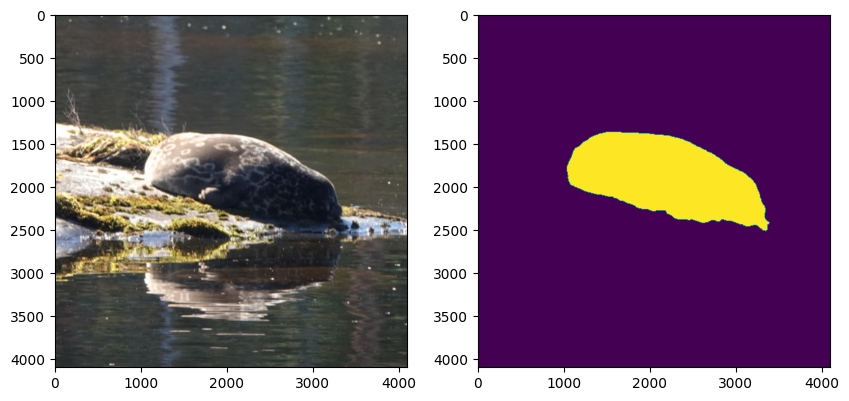

In [17]:
path = all_imgs[3]
print(path)
# path = '/home/veikka_immonen/GeoAware-SC/Navy_SEAL_Team_Platoon-1978225478.jpg'
img = Image.open(path)
imgs, out = get_mask(path, 'pusa saimensis')

_, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(img)
ax[1].imshow(out)


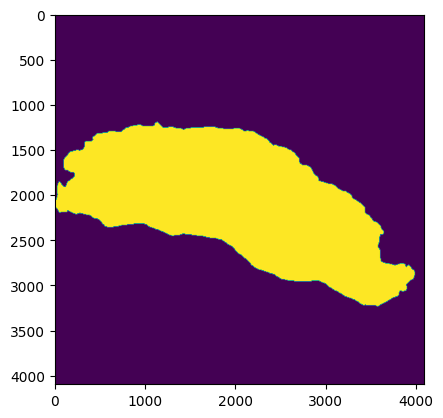

In [ ]:


labeled_array, num_features = label(out)
largest_label = np.argmax(np.bincount(labeled_array.ravel())[1:]) + 1
largest_blob = labeled_array == largest_label

filled_blob = binary_fill_holes(largest_blob)
plt.imshow(filled_blob)

In [ ]:
for i, r in df.iterrows():
    print(i)
    try:
        out = f'C:/Users/Alex/Downloads/22b5191e-f24b-4457-93d3-95797c900fc0_r__e_3m6/SealID/full images/masks_{r.reid_split}/{r.annotation_uuid}.png'
        if os.path.exists(out): 
            continue
        save_mask(r.path, out)
    except:
        continue